# **📖 Financial Transactions Fraud Detection Using ML**

**This project uses Machine Learning to analyze financial transactions and identify suspicious patterns. By learning from transaction history, the model can classify transactions as legitimate or potentially fraudulent, helping reduce financial losses and improve security.**

**Explore the data → Train the model → Detect fraud → Protect transactions! 🚀**

# **🚀Objective**

**To develop a Machine Learning-based fraud detection system that analyzes financial transaction patterns and accurately identifies suspicious or fraudulent transactions, helping improve financial security and minimize losses.**



##1. Importing the required libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report,precision_score,recall_score,f1_score
from sklearn.metrics import roc_auc_score , average_precision_score , confusion_matrix

## 2. Load the dataset

In [ ]:
data = pd.read_csv('/content/sample_data/onlinefraud.csv.zip')

## 3. EDA

In [ ]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
data.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
data.shape

(6362620, 11)

In [ ]:
cols = ['nameOrig','isFlaggedFraud','nameDest']
data.drop(columns=cols,axis=1,inplace=True)

In [ ]:
data.shape

(6362620, 8)

In [ ]:
data['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   oldbalanceOrg   float64
 4   newbalanceOrig  float64
 5   oldbalanceDest  float64
 6   newbalanceDest  float64
 7   isFraud         int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 388.3+ MB


In [ ]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00


In [ ]:
for col in data.columns :
  if(col == 'step' or col == 'type') :
    print(f"{col} unique values : {data[col].nunique()}")
    print(f"{data[col].unique()}")
    print("\n")

step unique values : 743
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 2

## 4. Feature Engineering

In [ ]:
data['orig_balance_error'] = data['oldbalanceOrg'] - data['amount'] - data['newbalanceOrig']
data['hour'] = data['step'] % 24
data['Is_night'] = data['hour'].between(0,5).astype(int)

In [ ]:
data

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_error,hour,Is_night
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0.0,1,1
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0.0,1,1
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0.0,1,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0.0,1,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,0.0,23,0
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0.0,23,0
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0.0,23,0
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0.0,23,0


** Downsampling the dataset from 6.3M rows to 50k rows while preserving all the positive classes **

In [ ]:
minority = data[data['isFraud'] == 1]
remaining = 50000 - len(minority)
majority = data[data['isFraud'] == 0].sample(remaining,random_state=42)
df = pd.concat([minority,majority]).sample(frac=1,random_state=42).reset_index(drop=True)

In [ ]:
df.shape

(50000, 11)

In [ ]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_error,hour,Is_night
0,46,CASH_IN,82812.61,94057.99,176870.60,591195.97,508383.36,0,-1.656252e+05,22,0
1,266,PAYMENT,3123.24,50036.00,46912.76,0.00,0.00,0,0.000000e+00,2,1
2,17,TRANSFER,305627.00,305627.00,0.00,0.00,0.00,1,0.000000e+00,17,0
3,137,PAYMENT,51680.70,243532.79,191852.09,0.00,0.00,0,2.910383e-11,17,0
4,359,CASH_IN,30096.99,7599823.47,7629920.46,106350.59,76253.60,0,-6.019398e+04,23,0
...,...,...,...,...,...,...,...,...,...,...,...
49995,382,CASH_OUT,542461.74,0.00,0.00,1757516.20,2299977.94,0,-5.424617e+05,22,0
49996,251,PAYMENT,16441.78,81962.00,65520.22,0.00,0.00,0,0.000000e+00,11,0
49997,353,CASH_OUT,54671.54,0.00,0.00,7006822.11,7061493.65,0,-5.467154e+04,17,0
49998,71,TRANSFER,1871553.73,1871553.73,0.00,0.00,0.00,1,0.000000e+00,23,0


In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0,41787
1,8213


In [ ]:
for Col in df.columns :
  if(Col == 'step' or Col == 'type' or Col == 'hour') :
    print(f"{Col} unique values : {df[Col].nunique()}")
    print(f"{df[Col].unique()}")
    print("\n")

step unique values : 743
[ 46 266  17 137 359 146 347 284 371 357 376 182 561 121 282 369 162 277
  18 688 554  24  68 276 134 206 254 393 307 324 235 495 351 227 141 133
 187 250 687 599 255 396 540 298 205 135  42 394 163 259 345 350 686 330
  14 160 189 211 437  61 352 398 209 375  43 395 184 251  34  44 226 204
 372 183 208  36 202 373 525 506 156 159 178 188  22 404  21  94 400 514
 697 402 210  48 132 349 275 370 260 646 354 280 406 500 358 155 610 191
 353 241 308 234 236 203  11 564 498 363 331 348  40 563 136 597 542 571
 544 355 306 546 718 138 543 382 249 523 399 158  26 240 157 179 242 621
 252 299 213  16 212 281 329 334 139  10 161 702 378 322 325   7 300 231
 332 716 427 164 303 140 278  33 119 311  13 617 485 629 143   9  38  12
  20 285 453  19 256 167 283 326  41 493  15 710 652 579 619  37 268 145
 180  47 366 575 717 595 490 229 356 594 186 397 732 130  35 274  60 258
 154 374 522 714 193 230 279 474 465  57 377 528 263 381 694 589 301 383
 424 712 185 321 587 225 7

## 5. Advanced EDA : Handling Outliers

In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_error,hour,Is_night
count,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000
mean,263.918380,3.931274e+05,9.522699e+05,7.322388e+05,1.006242e+06,1.233634e+06,0.164260,-1.730964e+05,14.705260,0.054020
std,163.539427,1.239935e+06,2.980458e+06,2.755142e+06,3.433557e+06,3.781655e+06,0.370515,6.228357e+05,5.009304,0.226059
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-6.988673e+07,0.000000,0.000000
25%,157.000000,1.703956e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-2.074972e+05,11.000000,0.000000
50%,254.000000,1.020985e+05,2.563800e+04,0.000000e+00,5.801229e+04,1.903888e+05,0.000000,-2.546994e+04,15.000000,0.000000
75%,355.000000,2.670287e+05,2.520595e+05,8.226374e+04,8.075893e+05,1.111801e+06,0.000000,0.000000e+00,19.000000,0.000000
max,743.000000,6.988673e+07,5.958504e+07,4.958504e+07,2.362305e+08,2.367265e+08,1.000000,1.000000e-02,23.000000,1.000000


In [ ]:
for i in df.columns :
  if i != 'type' and i != 'isFraud' and i != 'Is_night':
    print(f"{i} Skewness : {df[i].skew()}")

step Skewness : 0.5655790487515919
amount Skewness : 9.708005683013692
oldbalanceOrg Skewness : 5.535521681535879
newbalanceOrig Skewness : 5.845308179092974
oldbalanceDest Skewness : 24.770797088752087
newbalanceDest Skewness : 22.494559508758538
orig_balance_error Skewness : -41.89887362210838
hour Skewness : -0.7089484298410541


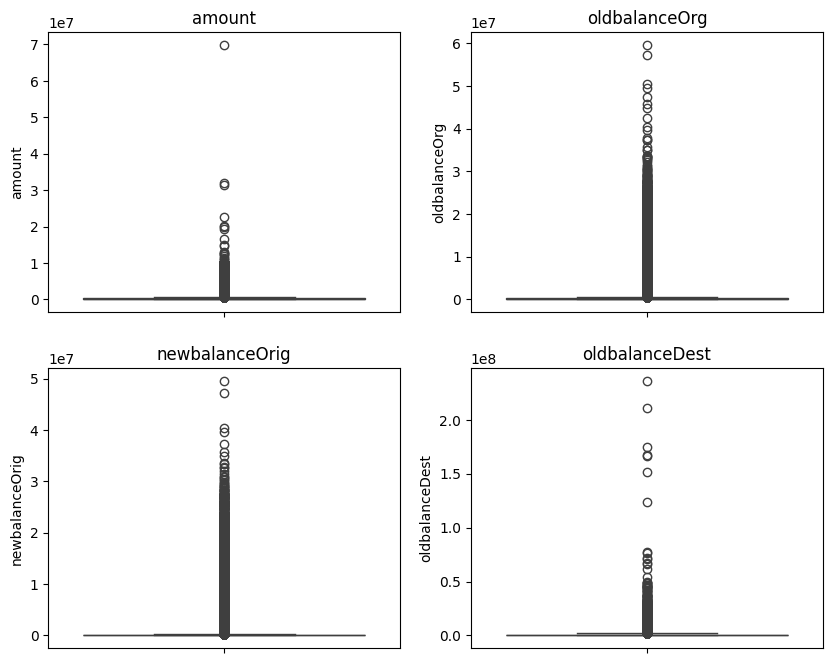

In [ ]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.boxplot(df['amount'])
plt.title('amount')
plt.subplot(2,2,2)
sns.boxplot(df['oldbalanceOrg'])
plt.title('oldbalanceOrg')
plt.subplot(2,2,3)
sns.boxplot(df['newbalanceOrig'])
plt.title('newbalanceOrig')
plt.subplot(2,2,4)
sns.boxplot(df['oldbalanceDest'])
plt.title('oldbalanceDest')
plt.show()

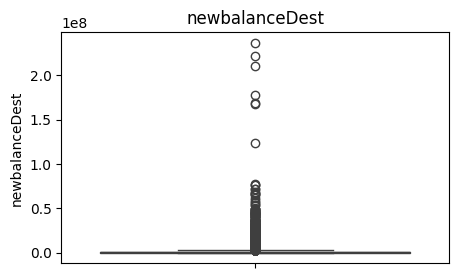

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(df['newbalanceDest'])
plt.title('newbalanceDest')
plt.show()

/tmp/ipykernel_940/2032115462.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['amount'])
/tmp/ipykernel_940/2032115462.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['oldbalanceOrg'])
/tmp/ipykernel_940/2032115462.py:9: UserWarning: 

`distplot` is a deprecated function and will b

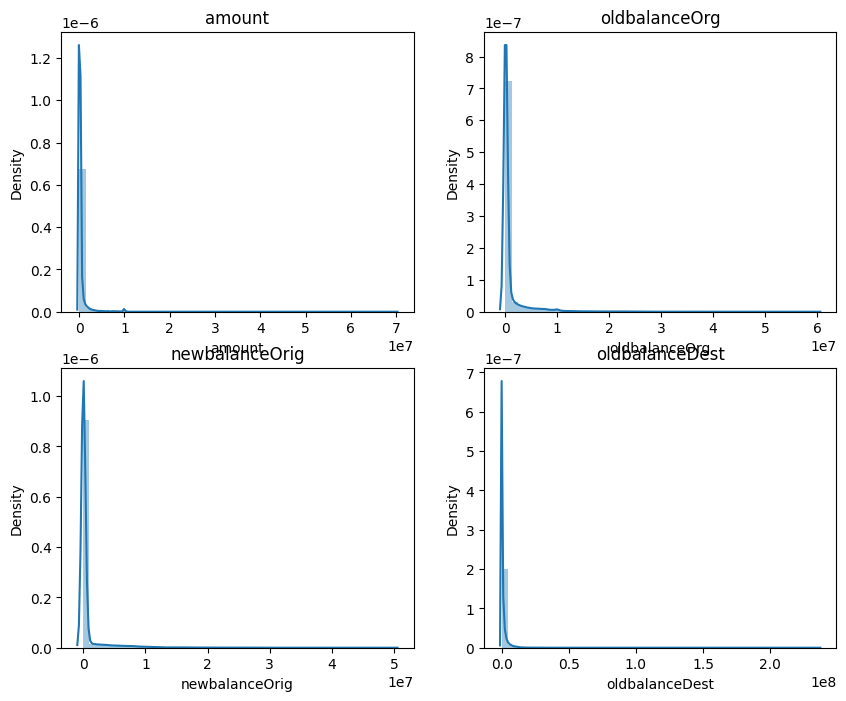

In [ ]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.distplot(df['amount'])
plt.title('amount')
plt.subplot(2,2,2)
sns.distplot(df['oldbalanceOrg'])
plt.title('oldbalanceOrg')
plt.subplot(2,2,3)
sns.distplot(df['newbalanceOrig'])
plt.title('newbalanceOrig')
plt.subplot(2,2,4)
sns.distplot(df['oldbalanceDest'])
plt.title('oldbalanceDest')
plt.show()

/tmp/ipykernel_940/996935532.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['newbalanceDest'])


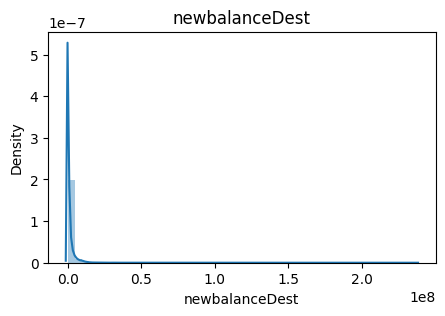

In [ ]:
plt.figure(figsize=(5,3))
sns.distplot(df['newbalanceDest'])
plt.title('newbalanceDest')
plt.show()

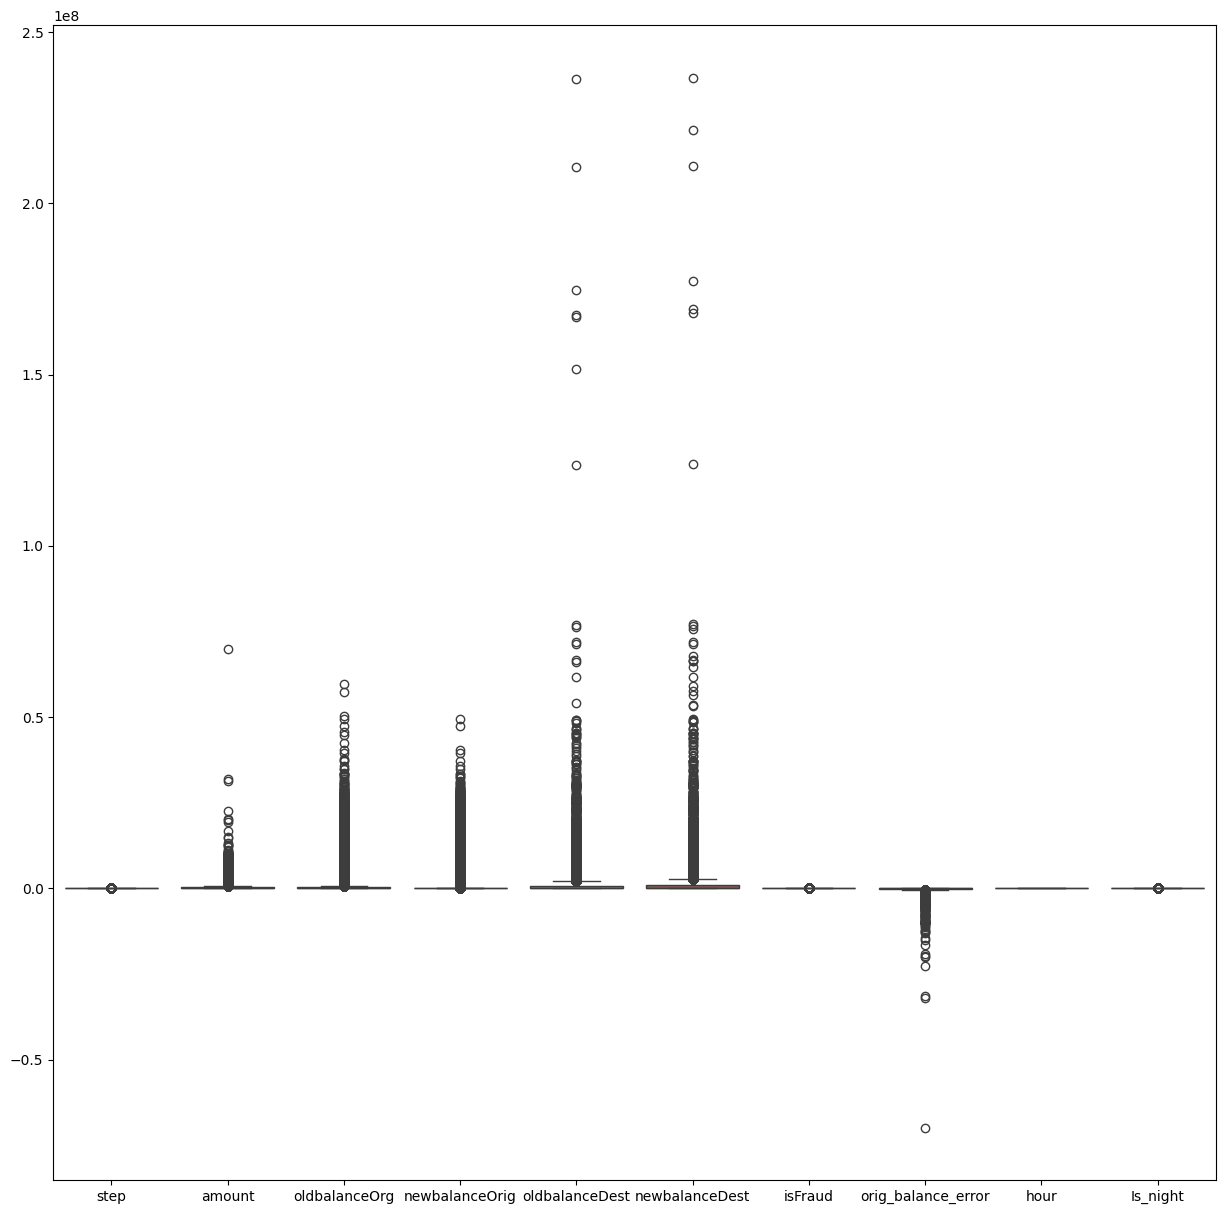

In [ ]:
fig,ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=df)
plt.show()

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'orig_balance_error',
       'hour', 'Is_night'],
      dtype='object')

**Applying Log Transformation to highly-skewed features to handle outliers**

In [ ]:
skewed_cols = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']
for j in skewed_cols :
  df[j] = np.log1p(df[j])

In [ ]:
for k in df.columns :
  if k != 'type' and k != 'isFraud' :
    print(f"{k} Skewness : {df[k].skew()}")

step Skewness : 0.5655790487515919
amount Skewness : -0.3677758990443681
oldbalanceOrg Skewness : -0.4920276941980466
newbalanceOrig Skewness : 0.7277139138788841
oldbalanceDest Skewness : -0.06662920933502503
newbalanceDest Skewness : -0.311081721419477
orig_balance_error Skewness : -41.89887362210838
hour Skewness : -0.7089484298410541
Is_night Skewness : 3.945846084745355


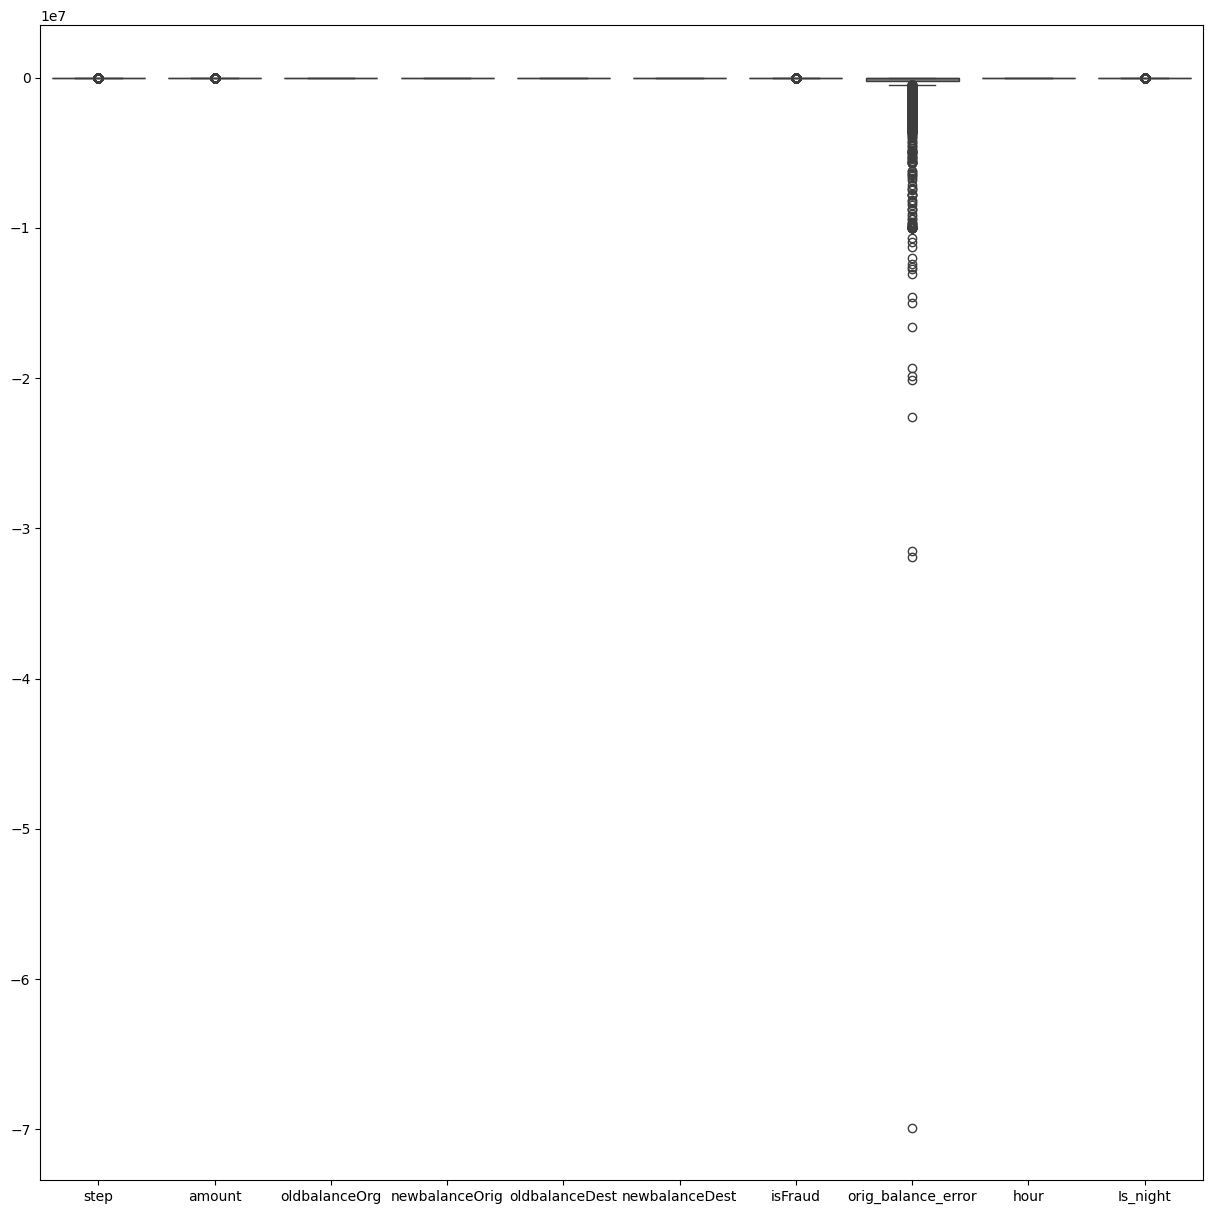

In [ ]:
fig,ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=df)
plt.show()

## 6. Feature Correlations

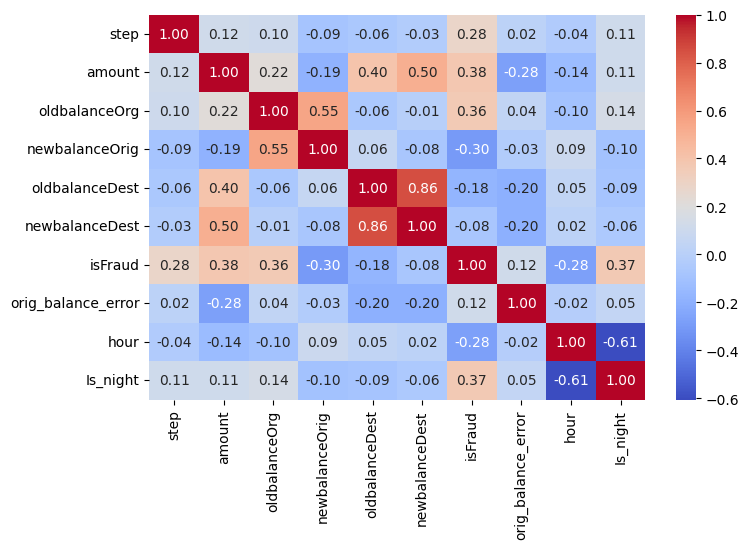

In [ ]:
plt.figure(figsize=(8,5))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.show()

**Dropping highly correlated features which doesn't provide any new information**

In [ ]:
df.drop(columns=['oldbalanceDest'],inplace=True,axis=1)

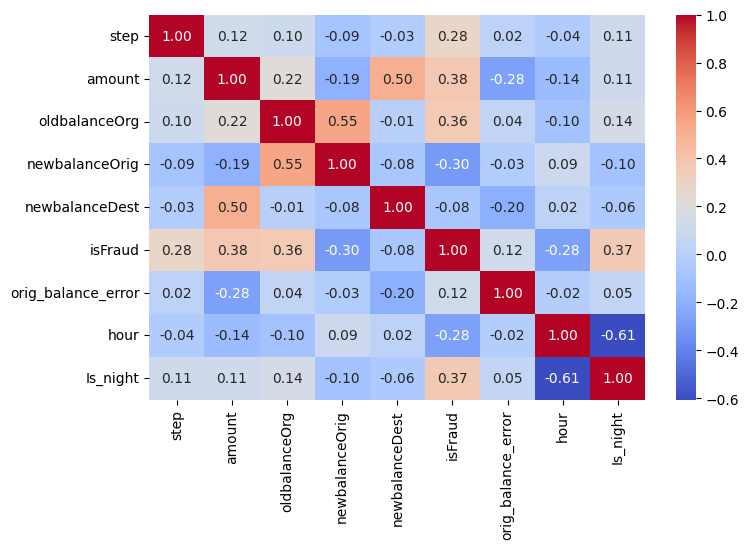

In [ ]:
plt.figure(figsize=(8,5))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.show()

## 7. Splitting the data into training and testing

In [ ]:
X = df.drop('isFraud',axis=1)
Y = df['isFraud']

In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(40000, 9)

In [ ]:
Y_train.value_counts()

,count
isFraud,
0,33427
1,6573


In [ ]:
X_test

,step,type,amount,oldbalanceOrg,newbalanceOrig,newbalanceDest,orig_balance_error,hour,Is_night
33553,377,CASH_IN,13.238747,14.955709,15.120893,13.279787,-1123424.20,17,0
9427,330,PAYMENT,9.698842,0.000000,0.000000,0.000000,-16297.72,18,0
199,203,CASH_OUT,11.564192,12.216459,11.480698,13.260831,0.00,11,0
12447,354,PAYMENT,7.082910,0.000000,0.000000,0.000000,-1190.43,18,0
39489,578,TRANSFER,12.183643,12.183643,0.000000,0.000000,0.00,2,1
...,...,...,...,...,...,...,...,...,...
28567,11,PAYMENT,8.127602,11.788674,11.762640,0.000000,0.00,11,0
25079,304,CASH_IN,11.505264,15.725762,15.740347,13.784883,-198471.62,16,0
18707,203,CASH_IN,11.323464,15.436792,15.453013,12.610601,-165478.95,11,0
15200,279,CASH_OUT,12.678016,9.966838,0.000000,12.981002,-299313.39,15,0


In [ ]:
X_train

,step,type,amount,oldbalanceOrg,newbalanceOrig,newbalanceDest,orig_balance_error,hour,Is_night
39087,667,CASH_OUT,12.969814,12.969814,0.000000,12.969814,0.000000e+00,19,0
30893,155,CASH_IN,12.972621,14.222874,14.474746,14.231705,-8.609273e+05,11,0
45278,374,CASH_OUT,12.824830,0.000000,0.000000,13.750270,-3.713230e+05,14,0
16398,47,PAYMENT,8.307553,10.575334,10.466060,0.000000,0.000000e+00,23,0
13653,251,CASH_IN,11.054232,15.447706,15.459988,12.643634,-1.264198e+05,11,0
...,...,...,...,...,...,...,...,...,...
11284,293,CASH_OUT,12.365956,12.365956,0.000000,13.153792,0.000000e+00,5,1
44732,134,CASH_OUT,12.866927,0.000000,0.000000,14.873529,-3.872883e+05,14,0
38158,297,TRANSFER,13.256848,0.000000,0.000000,14.296913,-5.719725e+05,9,0
860,308,PAYMENT,9.143641,9.287209,7.276031,0.000000,-2.273737e-13,20,0


In [ ]:
X_train.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'newbalanceDest', 'orig_balance_error', 'hour', 'Is_night'],
      dtype='object')

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 39087 to 15795
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   step                40000 non-null  int64  
 1   type                40000 non-null  object 
 2   amount              40000 non-null  float64
 3   oldbalanceOrg       40000 non-null  float64
 4   newbalanceOrig      40000 non-null  float64
 5   newbalanceDest      40000 non-null  float64
 6   orig_balance_error  40000 non-null  float64
 7   hour                40000 non-null  int64  
 8   Is_night            40000 non-null  int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 3.1+ MB


## 8. Scaling -> Numerical Features

  ##    Encoding -> Categorical Feature

In [ ]:
cat = ['type']
num = [i for i in X_train.columns if i != 'type' and i != 'Is_night']
print(num)

['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'newbalanceDest', 'orig_balance_error', 'hour']


In [ ]:
processor = ColumnTransformer(
    transformers = [
        ('scaler',StandardScaler(),num),
        ('OHE',OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop=['DEBIT']),cat)
    ],
    remainder = 'passthrough'
)

In [ ]:
X_train_df = processor.fit_transform(X_train)
X_test_df = processor.transform(X_test)
names = processor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_df,columns=names,index=X_train.index)
X_test_final = pd.DataFrame(X_test_df,columns=names,index=X_test.index)

In [ ]:
X_train_final

,scaler__step,scaler__amount,scaler__oldbalanceOrg,scaler__newbalanceOrig,scaler__newbalanceDest,scaler__orig_balance_error,scaler__hour,OHE__type_CASH_IN,OHE__type_CASH_OUT,OHE__type_PAYMENT,OHE__type_TRANSFER,remainder__Is_night
39087,2.463676,0.892830,0.832351,-0.733141,0.717885,0.329022,0.858387,0.0,1.0,0.0,0.0,0.0
30893,-0.665056,0.894238,1.055304,1.628170,0.905001,-1.328664,-0.739365,1.0,0.0,0.0,0.0,0.0
45278,0.673210,0.820042,-1.475321,-0.733141,0.833613,-0.385948,-0.140208,0.0,1.0,0.0,0.0,0.0
16398,-1.325023,-1.447811,0.406310,0.974220,-1.205312,0.329022,1.657264,0.0,0.0,1.0,0.0,0.0
13653,-0.078419,-0.068869,1.273234,1.788895,0.669518,0.085605,-0.739365,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.178235,0.589669,0.724909,-0.733141,0.745166,0.329022,-1.937679,0.0,1.0,0.0,0.0,1.0
44732,-0.793383,0.841176,-1.475321,-0.733141,1.000173,-0.416688,-0.140208,0.0,1.0,0.0,0.0,0.0
38158,0.202678,1.036932,-1.475321,-0.733141,0.914671,-0.772291,-1.138803,0.0,0.0,0.0,1.0,0.0
860,0.269897,-1.028062,0.177119,0.453821,-1.205312,0.329022,1.058107,0.0,0.0,1.0,0.0,0.0


##📌 Model Training : Using Class-Weights to handle Imbalanced-Data

In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced',penalty='l2',random_state=42),
    'Decision Tree' : DecisionTreeClassifier(class_weight='balanced',max_depth=6,min_samples_leaf=6,max_features='sqrt',random_state=42),
    'KNN' : KNeighborsClassifier(weights='distance',n_neighbors=15),
    'SVM' : SVC(class_weight='balanced',C=0.7,random_state=42),
    'RF' : RandomForestClassifier(class_weight='balanced',min_samples_leaf=5,max_features='sqrt',random_state=42)
}

for name , model in models.items() :
  model.fit(X_train_final,Y_train)
  print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
KNN trained successfully.
SVM trained successfully.
RF trained successfully.


## Model Prediction

In [ ]:
for name,model in models.items() :
  Y_pred = model.predict(X_test_final)
  print(f"{name} metrics : \n")
  print(f"Training score = {model.score(X_train_final,Y_train)}")
  print(f"Testing score = {model.score(X_test_final,Y_test)}")
  print("Classification Report : ")
  print(classification_report(Y_test,Y_pred))
  print("\n")
  print(confusion_matrix(Y_test,Y_pred))
  if name != 'SVM' :
    prob = model.predict_proba(X_test_final)[:,1]
    print(f"PR-AUC score : {average_precision_score(Y_test,prob)}")
    print(f"ROC score = {roc_auc_score(Y_test,prob)}")

Logistic Regression metrics : 

Training score = 0.9627
Testing score = 0.9662
Classification Report : 
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      8360
           1       0.84      0.99      0.91      1640

    accuracy                           0.97     10000
   macro avg       0.92      0.98      0.94     10000
weighted avg       0.97      0.97      0.97     10000



[[8041  319]
 [  19 1621]]
PR-AUC score : 0.9855334584558262
ROC score = 0.9948173649200607
Decision Tree metrics : 

Training score = 0.953375
Testing score = 0.951
Classification Report : 
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      8360
           1       0.77      1.00      0.87      1640

    accuracy                           0.95     10000
   macro avg       0.89      0.97      0.92     10000
weighted avg       0.96      0.95      0.95     10000



[[7875  485]
 [   5 1635]]
PR-AUC score : 0.948

## 📊 Feature Importance Plot for Tree based models

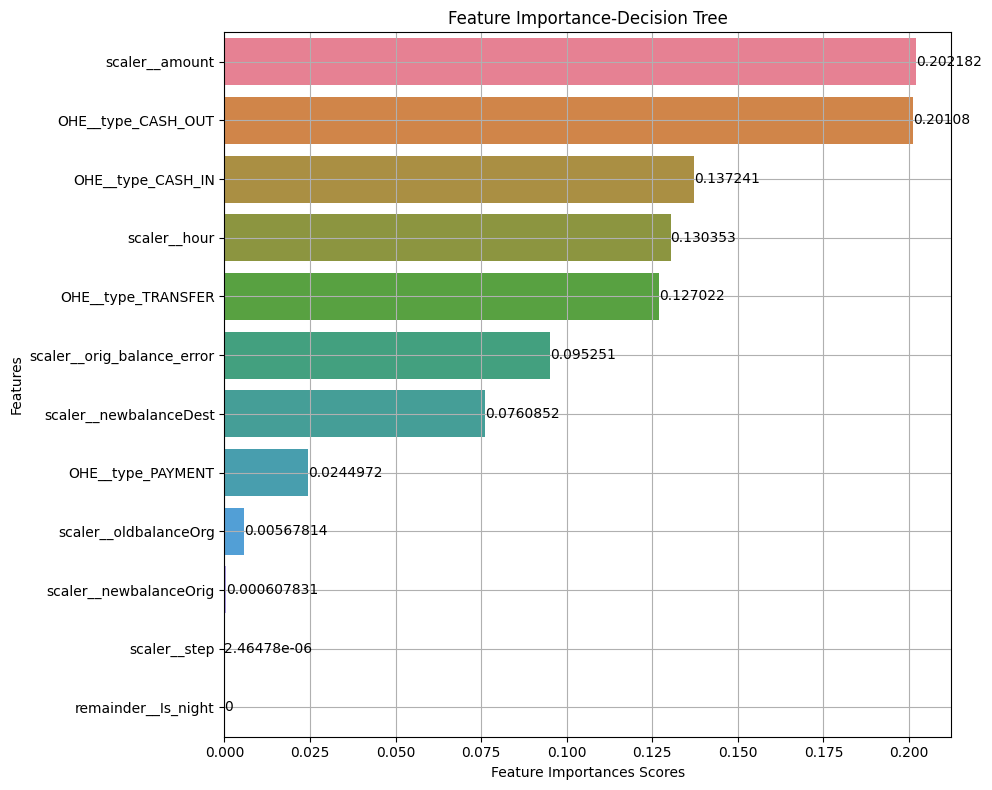

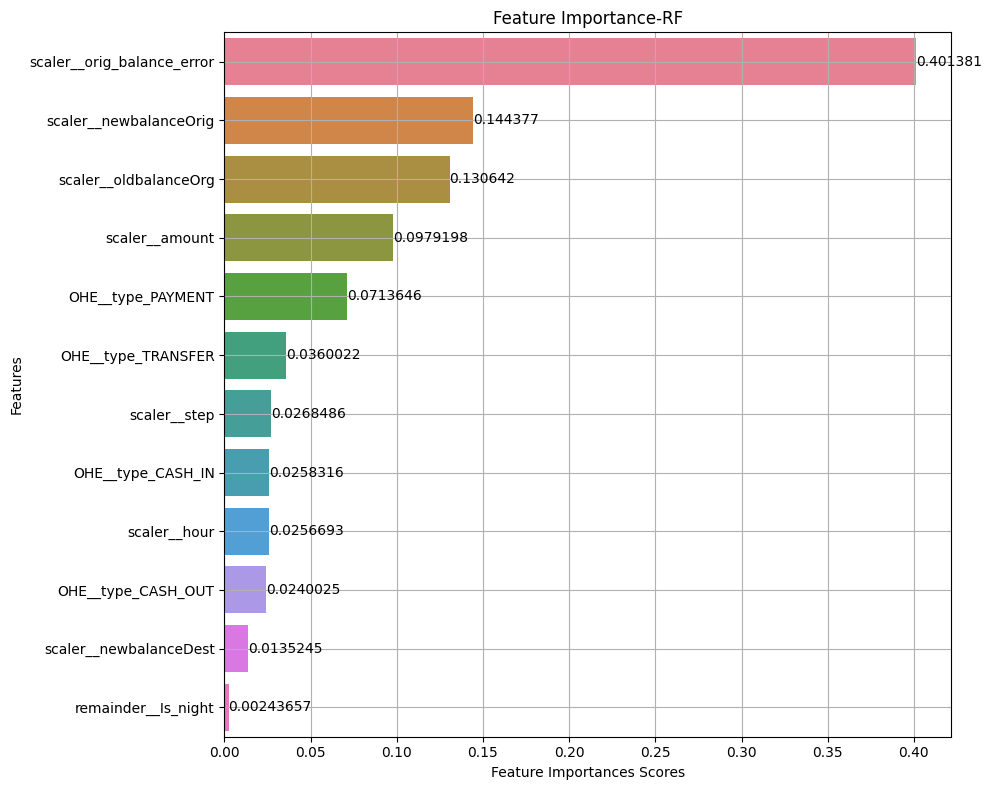

In [ ]:
for m_name,Models in models.items() :
  if m_name == 'RF' or m_name == 'Decision Tree':
    feature_importances = models[m_name].feature_importances_
    feature_names = X_train_final.columns
    importance_df = pd.DataFrame({
      'feature' : feature_names,
      'importance' : feature_importances
    }).sort_values('importance',ascending=False)
    plt.figure(figsize=(10,8))
    plot = sns.barplot(data=importance_df,y='feature',x='importance',hue='feature')
    for i in plot.containers :
      plot.bar_label(i)
    plt.grid()
    plt.title(f"Feature Importance-{m_name}")
    plt.xlabel("Feature Importances Scores")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

# **✅Conclusion**

**The project demonstrates how Machine Learning can effectively detect unusual transaction patterns and identify potential fraud. By automating fraud detection, the system can support faster decision-making, reduce financial risks, and enhance the overall security of financial transactions.**